Copyright (C) 2026  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 09/04/2026\
Brief Description: This notebook aims to use Fuzzy C-Means and K-Medoids to see which model can cluster wheat grain kernels more accurately based on a number of physical attributes. The dataset consists of 210 samples and the target variable has 3 values coressponding to Kama, Rosa and Canadian Wheat grains. This is a real dataset sourced from the UCI Machine Learning Repository. \
Source: [UCI Macine Learning Repository - Seeds](https://archive.ics.uci.edu/dataset/236/seeds)


In [9]:
# Needed imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
import skfuzzy as fuzz
from sklearn.metrics import adjusted_rand_score

from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix
from sklearn.metrics import adjusted_rand_score

# Random seed set for reproducibility
random.seed(42)
np.random.seed(42)

In [3]:
# Column names
columns = [
    "Area", "Perimeter", "Compactness", 
    "Kernel_Length", "Kernel_Width", 
    "Asymmetry_Coefficient", "Groove_Length", 
    "Class"
]

# Load dataset
dataset = pd.read_csv(
    "seeds_dataset.txt",
    sep=r"\s+",
    names=columns
)

dataset.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


### Preprocessing
The dataset is split into features X and target variable y. These features are then scaled using MinMaxScaler(), this ensures all the features are in a similar comparable range. The feature matrix is also transposed (flipped so that samples x features becomes features x samples). This is so X_scaled is in the format that the cmeans algorithm expects.

In [4]:
X = dataset.drop("Class", axis=1)
y = dataset["Class"]

# Scaling features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Transpose data for cmeans algorithm (expects features x samples)
X_scaled = X_scaled.T

Fuzzy C-Means (FCM) is a soft clustering algorithm which assigns a degree of membership to each datapoint for each cluster. This allows it to capture uncertainty and overlap between clusters.
#### Inputs
- X_scaled: this is the feature matrix.
- c=n_clusters: this is the number of clusters, there are 3 types of wheat in the dataset so this is set to 3.
- m=2: this is the fuzziness parameter, an m value of 1 means points cannot overlap between clusters making it a hard clustering method. An m value of 2 is standard for FCM algorithms allowing a fair amount of overlap between clusters.
- error=0.005: this is the convergence threshold, algorithm stops when improvement is less than this value.
- maxiter=1000: this is the maximum number of iterations allowed.
- init=None: this is the initial membership matrix, setting this to None means it is randomly initialised.
#### Outputs
- cntr: final cluster centres.
- u: final membership matrix. This is in the form (n_clusters, n_samples). Each datapoint gets a probability of being part of each cluster.
- fpc: Fuzzy Partition Coefficient. This measures the quality of clustering, closer to 1 means less overlap.

The argmax function takes in matrix u and assigns each datapoint to whichever cluster the model decided it had the highest probability of being part of.

In [5]:
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    X_scaled, 
    c=3, 
    m=2,
    error=0.005, 
    maxiter=1000, 
    init=None
)

# Gets cluster predictions (highest membership)
cluster_membership = np.argmax(u, axis=0)

In [6]:
# Adjusted Rand Index (compares clustering with true labels)
score = adjusted_rand_score(y, cluster_membership)

print(f"Adjusted Rand Index: {score:.4f}")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

Adjusted Rand Index: 0.7266
Fuzzy Partition Coefficient (FPC): 0.6820


The Adjusted Rand Index is a measure of how well the model predictions match the actual class labels. 0.7266 means the model was 72.66% accurate at classifying the wheat seeds. The Fuzzy Partition Coefficient defines how "fuzzy" the models predictions were, i.e. how much overlap there was. The plot below visualises the three clusters in two dimensions.

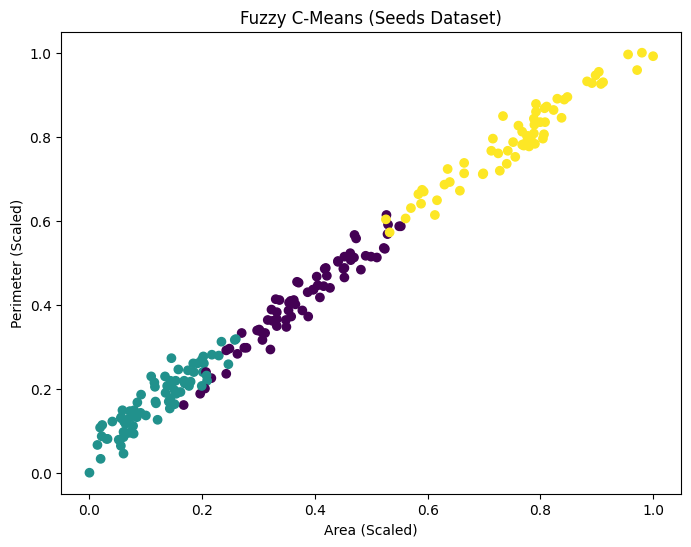

In [7]:
# Plot using first two features
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[0], 
    X_scaled[1], 
    c=cluster_membership, 
    cmap='viridis'
)

plt.title("Fuzzy C-Means (Seeds Dataset)")
plt.xlabel("Area (Scaled)")
plt.ylabel("Perimeter (Scaled)")
plt.show()

FCM is a soft clustering algorithm, this notebook will now compare this to a hard clustering algorithm called K-Medoids. K-Medoids is a hard clustering algorithm that splits data into clusters by selecting actual data points (medoids) as cluster centres and assigning each point to the nearest medoid based on a distance metric. It works by repeatedly selecting representative data points as cluster centres and updating cluster assignments so that each point is grouped with the medoid it is closest to, minimising the overall distance within clusters. The first code block transposes X_scaled back into the form samples x features, this is what the K-Medoids function expects.

In [16]:
# Transpose back to (samples x features)
X_samples = X_scaled.T  

initial_medoids = random.sample(range(len(X_samples)), 3)

The code block below initialises a K-Medoids model, runs the algorithm, extracts the clusters, assigns cluster ids and computes Adjusted Rand Index.

In [17]:
# Initialize K-Medoids
kmedoids_instance = kmedoids(data=X_samples, initial_index_medoids=initial_medoids)

# Run clustering
kmedoids_instance.process()

# Extract cluster labels
clusters = kmedoids_instance.get_clusters()

# Convert to label array (for ARI comparison)
kmedoids_labels = np.zeros(len(X_samples))
for cluster_id, cluster_points in enumerate(clusters):
    for idx in cluster_points:
        kmedoids_labels[idx] = cluster_id

In [18]:
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print(f"K-Medoids Adjusted Rand Index: {kmedoids_ari:.4f}")

K-Medoids Adjusted Rand Index: 0.7064


The Adjusted Rand Index value is 0.7064 which is slightly lower than the FCM model. K-Medoids performs worse because it forces strict cluster assignments in a dataset that naturally contains overlap between classes. For K-Medoids cluster centres must be a point in the dataset whereas for FCM centres can be computed as a mean value. FCM naturally performs better for soft, overlapping clusters. The plot below visualises the three clusters in two dimensions for comparison with the FCM plot however, there is little difference visually.

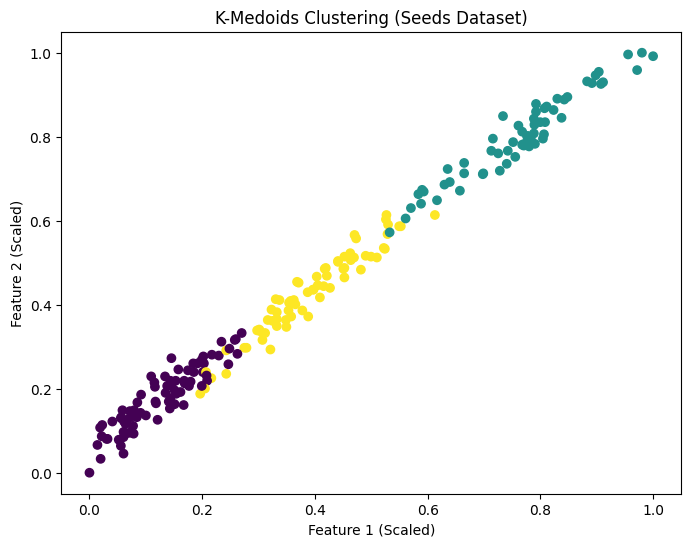

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(X_samples[:,0], X_samples[:,1], c=kmedoids_labels, cmap='viridis')
plt.title("K-Medoids Clustering (Seeds Dataset)")
plt.xlabel("Area (Scaled)")
plt.ylabel("Perimeter (Scaled)")
plt.show()

### Conclusion
To summarise, a Fuzzy C-Means model was used to cluster different kinds of wheat grains based on a number of physical attributes into three distinct clusters. This resulted in an Adjusted Rand Index value of 0.7266 indicating good model performance. K-Medoids was also used for the same task to compare the performance of the two models. This model achieved a value of 0.7064 which is slightly worse. This is likely due to the rigid, hard clustering nature of the K-Medoids algorithm. These results show that for this real-world task and dataset, where clusters are likely to have many overlapping points, Fuzzy C-Means performs better and is more suitable. 